Regression Analysis

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
# Load the dataset
file_path = r"C:\Users\debja\OneDrive\Desktop\DA Python Pandas Projects\Main Flow Internship tasks\Task 4\Mumbai House Prices.csv"

In [7]:
df = pd.read_csv(file_path)

In [9]:
# Display basic information
display(df.head())
display(df.info())
display(df.describe())

,bhk,type,locality,area,price,price_unit,region,status,age
0,3,Apartment,Lak And Hanware The Residency Tower,685,2.50,Cr,Andheri West,Ready to move,New
1,2,Apartment,Radheya Sai Enclave Building No 2,640,52.51,L,Naigaon East,Under Construction,New
2,2,Apartment,Romell Serene,610,1.73,Cr,Borivali West,Under Construction,New
3,2,Apartment,Soundlines Codename Urban Rainforest,876,59.98,L,Panvel,Under Construction,New
4,2,Apartment,Origin Oriana,659,94.11,L,Mira Road East,Under Construction,New


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76038 entries, 0 to 76037
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   bhk         76038 non-null  int64  
 1   type        76038 non-null  object 
 2   locality    76038 non-null  object 
 3   area        76038 non-null  int64  
 4   price       76038 non-null  float64
 5   price_unit  76038 non-null  object 
 6   region      76038 non-null  object 
 7   status      76038 non-null  object 
 8   age         76038 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 5.2+ MB


None

,bhk,area,price
count,76038.000000,76038.000000,76038.00000
mean,2.015111,1024.536850,29.38227
std,0.922754,670.276165,32.90345
min,1.000000,127.000000,1.00000
25%,1.000000,640.000000,1.75000
50%,2.000000,872.000000,5.50000
75%,3.000000,1179.000000,59.00000
max,10.000000,16000.000000,99.99000


In [11]:
# Check for missing values
display(df.isnull().sum())

bhk           0
type          0
locality      0
area          0
price         0
price_unit    0
region        0
status        0
age           0
dtype: int64

In [13]:
# Handling missing values (if any)
df = df.dropna()

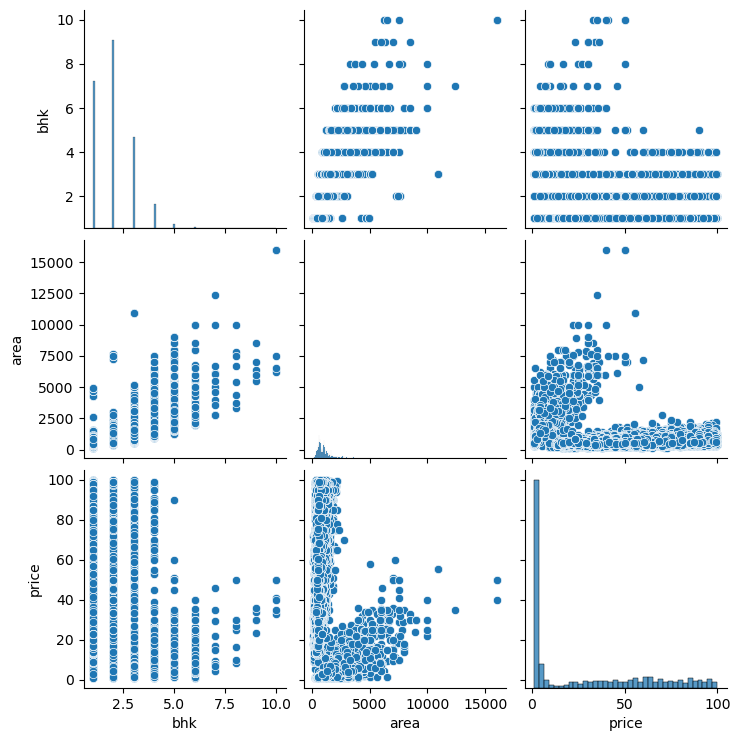

In [15]:
# Visualizing distributions
sns.pairplot(df)
plt.show()

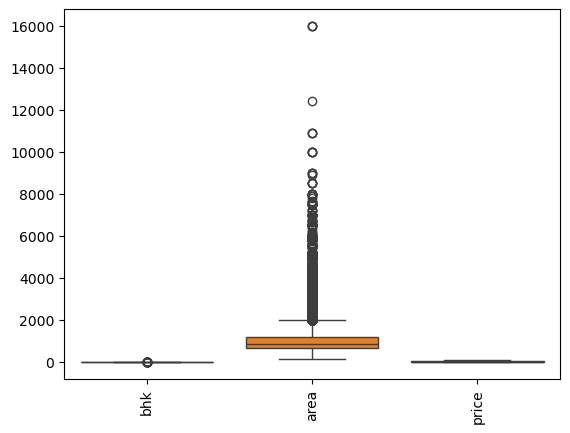

In [17]:
# Identifying outliers
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

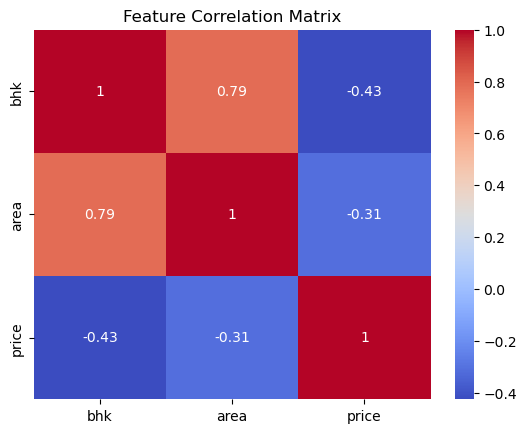

In [21]:
# Correlation Analysis (only for numerical columns)
correlation_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [25]:
print(df.columns)

Index(['bhk', 'type', 'locality', 'area', 'price', 'price_unit', 'region',
       'status', 'age'],
      dtype='object')


In [27]:
X = df.drop(columns=["price"])  # Try lowercase if needed
y = df["price"]

In [39]:
# Handling categorical variables
categorical_features = ["locality"]
numerical_features = ["area", "bhk"]

In [41]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

In [43]:
# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
# Creating pipeline
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [47]:
# Training the model
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['area', 'bhk']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['locality'])])),
                ('regressor', LinearRegression())])

In [49]:
# Making predictions
y_pred = pipeline.predict(X_test)

In [51]:
# Model evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [53]:
print(f"RMSE: {rmse}")
print(f"R² Score: {r2}")

RMSE: 22.626879640284763
R² Score: 0.5289071704038246


In [55]:
# Feature importance (for linear regression, we inspect coefficients)
feature_names = (numerical_features + list(pipeline.named_steps['preprocessor'].named_transformers_['cat']
                                           .get_feature_names_out(categorical_features)))
coef_df = pd.DataFrame({"Feature": feature_names, "Coefficient": pipeline.named_steps['regressor'].coef_})
display(coef_df.sort_values(by="Coefficient", ascending=False))

,Feature,Coefficient
6175,locality_Reputed Builder Sunrise Galaxy,85.050868
5132,locality_Reputed Builder Daffodil,80.890090
4943,locality_Reputed Builder Akshar Apartment,78.137478
3730,locality_Neelsidhi Balaji Garden,75.940863
1196,locality_Dattani Dattani Vertex,72.924919
...,...,...
1110,locality_D R Advent Neel Residency,-34.679824
3469,locality_Metro Vasupujya Darshan,-34.841351
4910,locality_Rensar Chistiya Palace,-35.006893
5769,locality_Reputed Builder Prerana CHS,-36.181589


In [67]:
# Effect of Location on Pricing
location_effects = coef_df[coef_df["Feature"].str.contains("locality_", regex=False)]
display(location_effects)

,Feature,Coefficient
2,locality_ AJ Shri Jay,35.139627
3,locality_ Akruti,-14.654436
4,locality_ Amber Heights,-7.563497
5,locality_ Arcade,45.509822
6,locality_ Asbury Park,-16.589549
...,...,...
8978,locality_Zee Heights,-25.890602
8979,locality_Zee Swastik,-27.970917
8980,locality_Zee Tulsi,-24.367772
8981,locality_Zire The Kollage,-21.692584


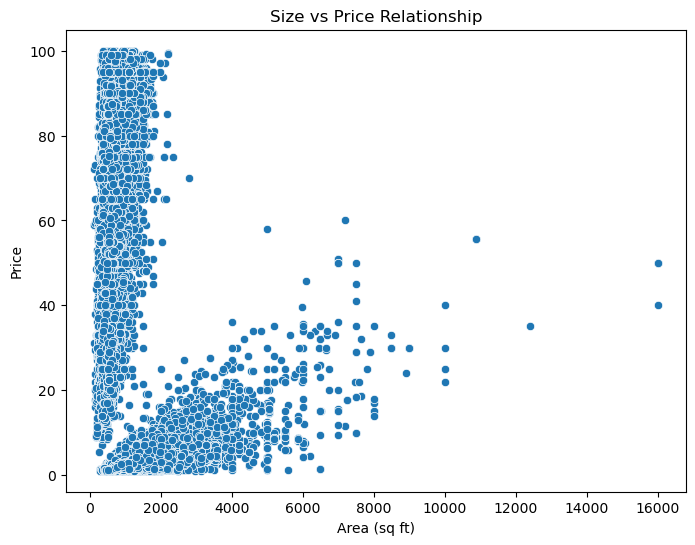

In [71]:
# Scatter plot of Size vs Price
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['area'], y=df['price'])
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.title("Size vs Price Relationship")
plt.show()

Here’s what we can infer from the Price vs Area plot:

- General Trend
There is a positive correlation between house size and price—as the area increases, the price generally tends to go up.
However, the data is highly skewed towards smaller houses, meaning a majority of houses in the dataset are below 2000 sq ft.

- Key Observations
- Dense Cluster on the Left (0 - 2000 sq ft)
The majority of houses are small-sized (below 2000 sq ft), but their prices vary significantly. Some of these small houses still have high prices, suggesting that location, amenities, or other factors play a role.
- Sparse Data for Large Houses (5000+ sq ft)
Houses above 5000 sq ft are fewer, but they generally have higher prices. A few exceptions exist where large houses have relatively lower prices, possibly due to location disadvantages or other factors.

- Price Variability and Other Influencing Factors
The price variation for a given area size suggests that size alone isn’t the only determinant of price.
- Possible influencing factors:
- Location (prime areas can make even small houses expensive).
- Quality & Amenities (luxury apartments vs. regular flats).
- Market Demand (some large houses may not have high demand).

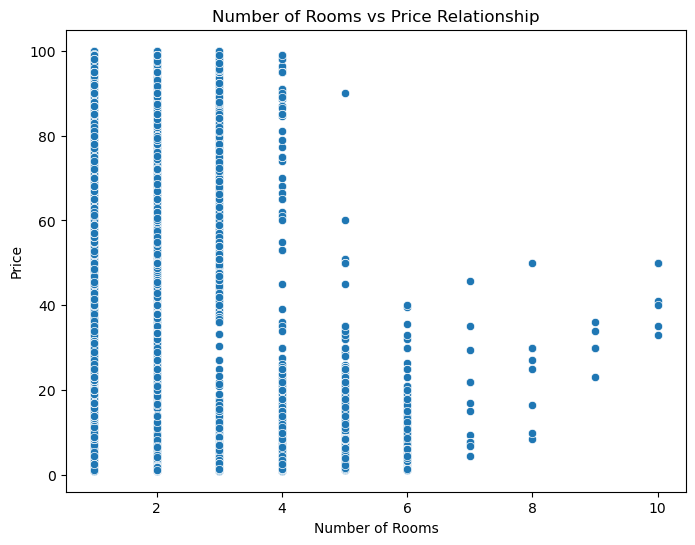

In [73]:
# Scatter plot of Number of Rooms vs Price
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['bhk'], y=df['price'])
plt.xlabel("Number of Rooms")
plt.ylabel("Price")
plt.title("Number of Rooms vs Price Relationship")
plt.show()

Here's what we can observe from the above plot of Price vs No of Rooms:

-1️⃣ Trend Overview
a) There seems to be a positive correlation between the number of rooms and house price—as the number of rooms increases, house prices generally tend to be higher.
b) However, the spread of points suggests high variability, meaning other factors (like location, size, or amenities) also impact house prices.

-2️⃣ Key Observations
a) Clustered Points for Lower Room Counts (1-4 Rooms):
Most houses fall within the 1 to 4-room range, with prices spanning a wide range (from low to high). This suggests that smaller houses can still have high prices, likely due to location or other premium features.
b) Sparser Data for Higher Room Counts (5+ Rooms):
Houses with 5+ rooms are fewer, but their prices are more dispersed. Some of these houses still have relatively low prices, suggesting that size alone doesn’t determine the price.

-3️⃣ Possible Factors Affecting Price Variation
a) Location: Houses in prime locations might be expensive even with fewer rooms.
b) Amenities & Features: Luxury apartments might have higher prices despite having fewer rooms.
c) Total Square Footage: A house with many small rooms might be cheaper than one with fewer but larger rooms.